In [1]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import hypergeom, spearmanr

In [2]:
INPUT = "/kaggle/input/datasets/nocturnalnerd18"
OUT_DIR = "/kaggle/working/dla_intern_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

TYPES = ["attribute", "relation"]
N_LAYER, N_HEAD = 28, 28
N_COMP = N_LAYER * N_HEAD + N_LAYER + 1

MIN_GROUP = 10
MIN_BIN = 5
N_BINS = 8
N_PERM = 500
K_TOP = 20
MIN_LOGITS = 0.05

CONTRASTS = {
    "flip": ("false_yes", "true_no", 1),
    "evidence": ("false_yes", "true_yes", 1),
    "evidence_matched": ("false_yes", "true_yes", N_BINS),
}
UNITS = {
    "attribute": ("attribute", None),
    "relation/reefknot": ("relation", "reefknot"),
    "relation/amber": ("relation", "amber"),
}
PLOT_UNITS = ["attribute", "relation/reefknot"]

with open(f"{INPUT}/dla-intern/dla_meta.json") as f:
    dla_meta = json.load(f)
YES_IDS, NO_IDS = dla_meta["yes_ids"], dla_meta["no_ids"]
assert dla_meta["n_layer"] == N_LAYER and dla_meta["n_head"] == N_HEAD


def batch_number(path):
    return int(re.search(r"_batch_(\d+)\.pt$", path).group(1))


meta, attn, mlp, embed, logit_diff = [], [], [], [], []
for t in TYPES:
    for path in sorted(glob.glob(f"{INPUT}/dla-intern/{t}_batch_*.pt"), key=batch_number):
        for e in torch.load(path):
            meta.append({k: e[k] for k in ("question_id", "hallucination_type", "ground_truth_answer", "prefix", "in_pair", "top_id", "stratum")})
            attn.append(e["attn"] / e["rms"])
            mlp.append(e["mlp"] / e["rms"])
            embed.append((e["embed"] / e["rms"]).item())
            logit_diff.append(e["logit_diff"].item())

dla = pd.DataFrame(meta)
dla["row"] = np.arange(len(dla))
dla["logit_diff"] = logit_diff
dla["source"] = dla["prefix"].str.rstrip("_")
FEATURES = np.concatenate([
    torch.stack(attn).reshape(len(dla), -1).numpy(),
    torch.stack(mlp).numpy(),
    np.array(embed, dtype=np.float32)[:, None],
], axis=1).astype(np.float32)
assert FEATURES.shape[1] == N_COMP, FEATURES.shape

completeness_err = np.abs(FEATURES.sum(1) - dla["logit_diff"].to_numpy()).max()
print(len(dla), "dla entries,", FEATURES.shape[1], "components each")
print(f"components vs model logit diff, max abs err: {completeness_err:.4f}")
assert completeness_err < 0.5, "components do not reproduce the logit difference"
assert np.isfinite(FEATURES).all(), "non-finite components"

7003 dla entries, 813 components each
components vs model logit diff, max abs err: 0.0260


In [3]:
with open(f"{INPUT}/vlm-labeled-examples/labeled_examples.json") as f:
    labels = pd.DataFrame(json.load(f))
assert "cache" in labels.columns, "attach vlm-labeled-examples version 3"
labels = labels[labels["cache"] == "question_aware"][["question_id", "split"]]

df = dla.merge(labels, on="question_id", how="inner")
print(len(dla), "dla entries,", len(df), "joined to a split")
assert len(df) > 0.99 * len(dla), "most dla entries have no split"

df["truth"] = df["ground_truth_answer"].str.strip().str.lower()
df["model_answer"] = np.where(df.logit_diff > 0, "yes", "no")
df["group"] = np.select(
    [
        (df.truth == "yes") & (df.model_answer == "yes"),
        (df.truth == "no") & (df.model_answer == "no"),
        (df.truth == "no") & (df.model_answer == "yes"),
        (df.truth == "yes") & (df.model_answer == "no"),
    ],
    ["true_yes", "true_no", "false_yes", "false_no"],
    default="other",
)
assert (df.group != "other").all()

pair_rows = df[df.in_pair]
top_yes = np.array([t in YES_IDS[p] for t, p in zip(pair_rows.top_id, pair_rows.prefix)])
agree = float((top_yes == (pair_rows.logit_diff > 0).to_numpy()).mean())
print(f"in_pair top-1 agrees with the sign of the averaged gap on {agree:.4f} of rows")
assert agree > 0.97, "in_pair top-1 disagrees with the sign of the averaged gap"


def unit_mask(unit, pair_only=True):
    t, source = UNITS[unit]
    mask = df.hallucination_type.eq(t)
    if source is not None:
        mask &= df.source.eq(source)
    if pair_only:
        mask &= df.in_pair
    return mask


def count_rows(unit, group, splits, pair_only=True):
    return int((unit_mask(unit, pair_only) & df.group.eq(group) & df.split.isin(splits)).sum())


print(pd.crosstab([df.hallucination_type, df.source], df.in_pair, normalize="index").round(4))
for unit in UNITS:
    sub = df[unit_mask(unit, pair_only=False)]
    print(f"--- {unit}: top-1 in the yes/no pair by group ---")
    print(pd.crosstab(sub.group, sub.in_pair, margins=True))
print(pd.crosstab([df.hallucination_type, df.source, df.split], df[df.in_pair].group))
print(pd.crosstab(df.stratum, df.group))

7003 dla entries, 7003 joined to a split
in_pair top-1 agrees with the sign of the averaged gap on 0.9871 of rows
in_pair                       False   True 
hallucination_type source                  
attribute          amber     0.1058  0.8942
relation           amber     0.2066  0.7934
                   reefknot  0.0000  1.0000
--- attribute: top-1 in the yes/no pair by group ---
in_pair    False  True   All
group                       
false_no      19     0    19
false_yes    205   413   618
true_no       70  1034  1104
true_yes      61  1552  1613
All          355  2999  3354
--- relation/reefknot: top-1 in the yes/no pair by group ---
in_pair    True   All
group                
false_yes  1297  1297
true_no     611   611
true_yes   1015  1015
All        2923  2923
--- relation/amber: top-1 in the yes/no pair by group ---
in_pair    False  True  All
group                      
false_no      38     0   38
false_yes      0     8    8
true_no       88   267  355
true_yes      24   

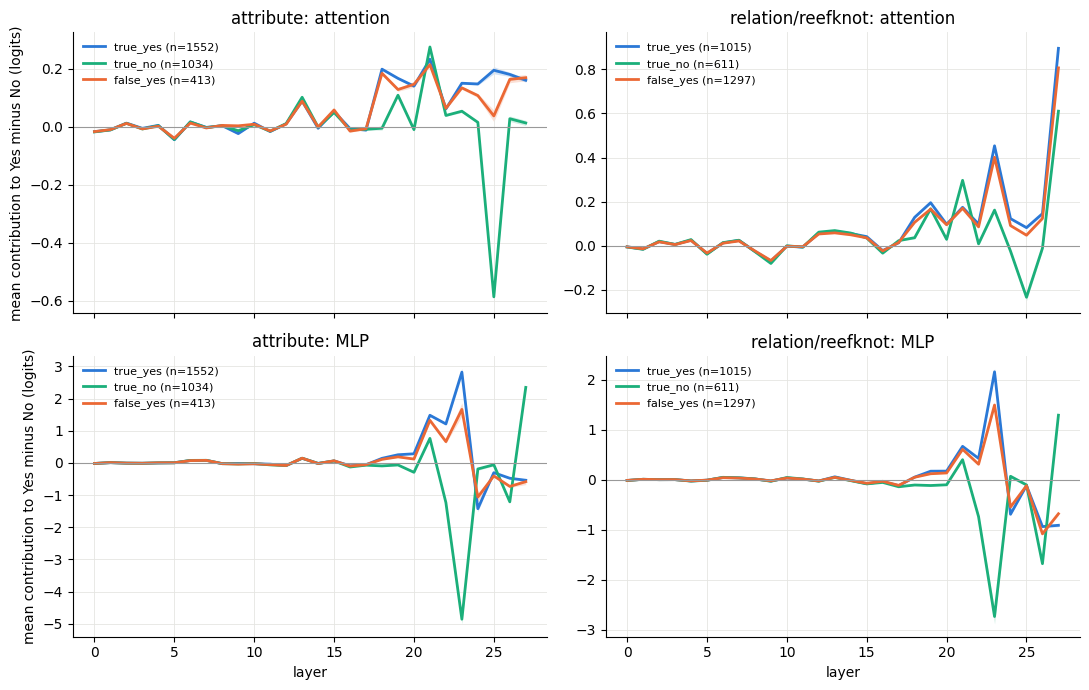

In [4]:
GROUP_COLORS = {"true_yes": "#2a78d6", "true_no": "#1baf7a", "false_yes": "#eb6834"}
UNIT_COLORS = {"attribute": "#2a78d6", "relation/reefknot": "#1baf7a", "relation/amber": "#eb6834"}
layer_axis = np.arange(N_LAYER)
attn_layer = FEATURES[:, :N_LAYER * N_HEAD].reshape(-1, N_LAYER, N_HEAD).sum(2)
mlp_layer = FEATURES[:, N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER]

fig, axes = plt.subplots(2, len(PLOT_UNITS), figsize=(5.5 * len(PLOT_UNITS), 7), sharex=True)
for col, unit in enumerate(PLOT_UNITS):
    for row, (name, arr) in enumerate([("attention", attn_layer), ("MLP", mlp_layer)]):
        ax = axes[row, col]
        for g, color in GROUP_COLORS.items():
            x = arr[df[unit_mask(unit) & df.group.eq(g)].row.to_numpy()]
            if len(x) < 2:
                continue
            m, se = x.mean(0), x.std(0, ddof=1) / np.sqrt(len(x))
            ax.plot(layer_axis, m, color=color, lw=2, label=f"{g} (n={len(x)})")
            ax.fill_between(layer_axis, m - 1.96 * se, m + 1.96 * se, color=color, alpha=0.2, lw=0)
        ax.axhline(0, color="#999999", lw=0.8)
        ax.set_title(f"{unit}: {name}")
        ax.grid(color="#e5e5e2", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
        if col == 0:
            ax.set_ylabel("mean contribution to Yes minus No (logits)")
        if row == 1:
            ax.set_xlabel("layer")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/layer_profiles.png", dpi=150)
plt.show()

In [5]:
def comp_name(i):
    if i < N_LAYER * N_HEAD:
        return f"L{i // N_HEAD} H{i % N_HEAD}"
    if i < N_LAYER * N_HEAD + N_LAYER:
        return f"L{i - N_LAYER * N_HEAD} MLP"
    return "embed"


def build_strata(unit, g_a, g_b, splits, n_bins, pair_only=True):
    sub_all = df[unit_mask(unit, pair_only) & df.group.isin([g_a, g_b]) & df.split.isin(splits)]
    strata = []
    for _, sub in sub_all.groupby("source"):
        if n_bins > 1:
            edges = np.quantile(sub.logit_diff, np.linspace(0, 1, n_bins + 1)[1:-1])
            parts = [p for _, p in sub.groupby(np.digitize(sub.logit_diff, edges))]
            min_group = MIN_BIN
        else:
            parts, min_group = [sub], MIN_GROUP
        for part in parts:
            is_a = part.group.eq(g_a).to_numpy()
            if is_a.sum() < min_group or (~is_a).sum() < min_group:
                continue
            X = FEATURES[part.row.to_numpy()].astype(np.float64)
            strata.append((X, X ** 2, is_a))
    return strata


def effects(strata, masks):
    d_sum, m_sum, w_sum = np.zeros(N_COMP), np.zeros(N_COMP), 0.0
    for (X, X2, _), mask in zip(strata, masks):
        na, nb = mask.sum(), (~mask).sum()
        mf = mask.astype(np.float64)
        sa, sa2 = mf @ X, mf @ X2
        sb, sb2 = X.sum(0) - sa, X2.sum(0) - sa2
        ma, mb = sa / na, sb / nb
        va, vb = (sa2 - na * ma ** 2) / (na - 1), (sb2 - nb * mb ** 2) / (nb - 1)
        sp = np.sqrt(np.maximum(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2), 0))
        w = na * nb / (na + nb)
        d_sum += w * (ma - mb) / np.maximum(sp, 1e-6)
        m_sum += w * (ma - mb)
        w_sum += w
    return d_sum / w_sum, m_sum / w_sum


def perm_null(strata, seed=0):
    rng = np.random.default_rng(seed)
    null = np.empty(N_PERM)
    for b in range(N_PERM):
        d, _ = effects(strata, [rng.permutation(mask) for _, _, mask in strata])
        null[b] = np.abs(d).max()
    return null

In [6]:
results = {}
for unit in UNITS:
    for cname, (g_a, g_b, n_bins) in CONTRASTS.items():
        train = build_strata(unit, g_a, g_b, ["train"], n_bins)
        held = build_strata(unit, g_a, g_b, ["val", "test"], n_bins)
        if not train or not held:
            print(f"{unit:18s} {cname:17s} not enough examples, skipped")
            continue
        d_train, m_train = effects(train, [m for _, _, m in train])
        d_held, m_held = effects(held, [m for _, _, m in held])
        null95 = float(np.quantile(perm_null(train), 0.95))
        n_a = int(sum(m.sum() for _, _, m in train))
        n_b = int(sum((~m).sum() for _, _, m in train))
        material = (
            (np.abs(d_train) > null95) & (np.sign(m_train) == np.sign(m_held)) & (np.abs(m_train) >= MIN_LOGITS)
        )
        results[(unit, cname)] = {
            "d_train": d_train, "m_train": m_train, "d_held": d_held, "m_held": m_held,
            "null95": null95, "n_a": n_a, "n_b": n_b, "material": material,
        }
        print(f"{unit:18s} {cname:17s} {g_a} {n_a}/{count_rows(unit, g_a, ['train'])} vs {g_b} {n_b} | "
              f"residual logit gap {m_train.sum():+.3f} | null95 {null95:.3f} | "
              f"significant {int((np.abs(d_train) > null95).sum())} | material {int(material.sum())}")

attribute          flip              false_yes 284/284 vs true_no 717 | residual logit gap +7.722 | null95 0.272 | significant 312 | material 28
attribute          evidence          false_yes 284/284 vs true_yes 1087 | residual logit gap -2.458 | null95 0.257 | significant 195 | material 11
attribute          evidence_matched  false_yes 284/284 vs true_yes 1087 | residual logit gap -0.078 | null95 0.292 | significant 180 | material 3
relation/reefknot  flip              false_yes 905/905 vs true_no 424 | residual logit gap +5.205 | null95 0.228 | significant 597 | material 32
relation/reefknot  evidence          false_yes 905/905 vs true_yes 707 | residual logit gap -0.939 | null95 0.199 | significant 389 | material 6
relation/reefknot  evidence_matched  false_yes 905/905 vs true_yes 707 | residual logit gap -0.009 | null95 0.206 | significant 149 | material 0
relation/amber     flip              not enough examples, skipped
relation/amber     evidence          not enough examples, ski

In [7]:
for (unit, cname), r in results.items():
    gap = r["m_train"].sum()
    top = np.argsort(-np.abs(r["m_train"]))[:K_TOP]
    print(f"--- {unit} / {cname}: {r['n_a']} vs {r['n_b']} train questions, mean logit gap {gap:+.3f} ---")
    print(f"material components: {int(r['material'].sum())} | top-{K_TOP} by logits net {r['m_train'][top].sum():+.3f} of the gap")
    table = pd.DataFrame({
        "component": [comp_name(i) for i in top[:10]],
        "depth": [f"{(i // N_HEAD if i < N_LAYER * N_HEAD else i - N_LAYER * N_HEAD if i < N_COMP - 1 else 0) / N_LAYER:.0%}" for i in top[:10]],
        "logits_train": r["m_train"][top[:10]].round(3),
        "logits_held": r["m_held"][top[:10]].round(3),
        "d_train": r["d_train"][top[:10]].round(2),
        "material": r["material"][top[:10]],
    })
    print(table.to_string(index=False))

--- attribute / flip: 284 vs 717 train questions, mean logit gap +7.722 ---
material components: 28 | top-20 by logits net +6.732 of the gap
component depth  logits_train  logits_held  d_train  material
  L23 MLP   82%         6.546        6.468     2.79      True
  L27 MLP   96%        -2.993       -2.795    -3.11      True
  L22 MLP   79%         1.896        1.895     3.15      True
  L24 MLP   86%        -0.816       -1.003    -0.85      True
  L21 MLP   75%         0.551        0.586     0.98      True
  L26 MLP   93%         0.520        0.387     0.97      True
  L20 MLP   71%         0.418        0.399     2.06      True
  L25 H17   89%         0.402        0.374     2.46      True
  L25 MLP   89%        -0.350       -0.341    -0.70      True
  L26 H22   93%        -0.328       -0.328    -3.32      True
--- attribute / evidence: 284 vs 1087 train questions, mean logit gap -2.458 ---
material components: 11 | top-20 by logits net -2.291 of the gap
component depth  logits_train  

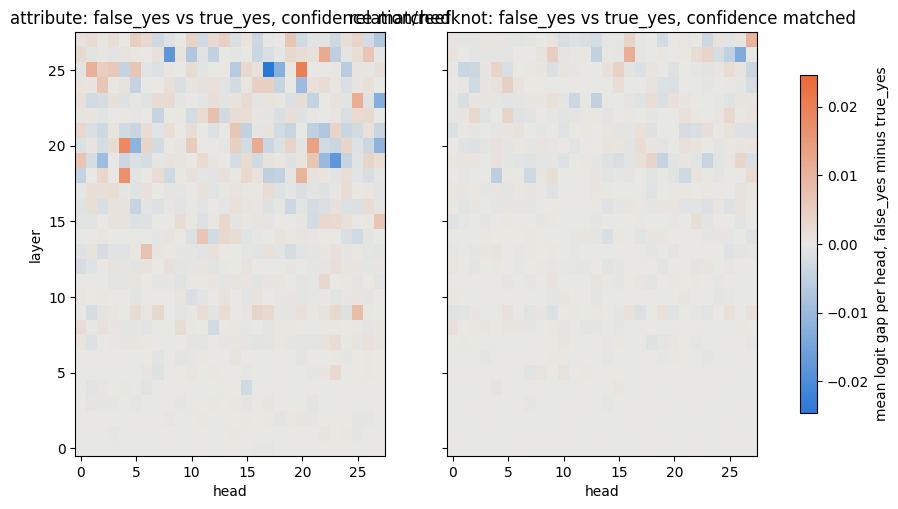

In [8]:
DIVERGING = LinearSegmentedColormap.from_list("dla_div", ["#2a78d6", "#e8e8e4", "#eb6834"])
plot_units = [u for u in PLOT_UNITS if (u, "evidence_matched") in results]
head_m = {u: results[(u, "evidence_matched")]["m_train"][:N_LAYER * N_HEAD] for u in plot_units}
limit = max(np.abs(v).max() for v in head_m.values())

fig, axes = plt.subplots(1, len(plot_units), figsize=(5.5 * len(plot_units), 5.5), sharey=True, squeeze=False)
for ax, unit in zip(axes[0], plot_units):
    im = ax.imshow(head_m[unit].reshape(N_LAYER, N_HEAD), origin="lower", cmap=DIVERGING, vmin=-limit, vmax=limit, aspect="auto")
    ys, xs = np.nonzero(results[(unit, "evidence_matched")]["material"][:N_LAYER * N_HEAD].reshape(N_LAYER, N_HEAD))
    ax.scatter(xs, ys, s=10, color="#0b0b0b")
    ax.set_title(f"{unit}: false_yes vs true_yes, confidence matched")
    ax.set_xlabel("head")
axes[0, 0].set_ylabel("layer")
fig.colorbar(im, ax=axes.ravel().tolist(), label="mean logit gap per head, false_yes minus true_yes", shrink=0.8)
plt.savefig(f"{OUT_DIR}/head_effects_matched.png", dpi=150, bbox_inches="tight")
plt.show()

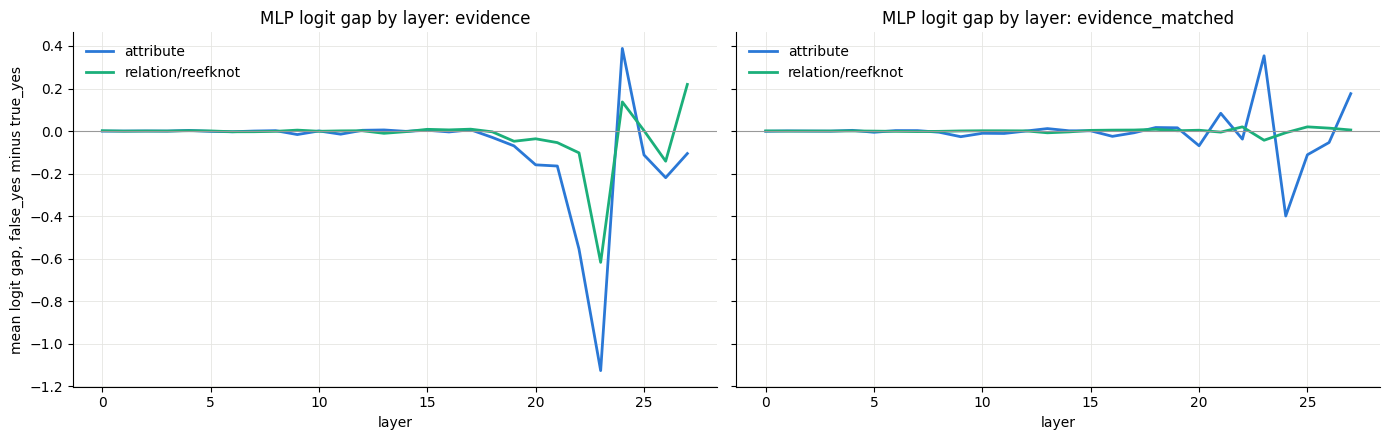

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, cname in zip(axes, ["evidence", "evidence_matched"]):
    for unit in UNITS:
        if (unit, cname) not in results:
            continue
        r = results[(unit, cname)]
        ax.plot(layer_axis, r["m_train"][N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER], color=UNIT_COLORS[unit], lw=2, label=unit)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.set_title(f"MLP logit gap by layer: {cname}")
    ax.set_xlabel("layer")
    ax.grid(color="#e5e5e2", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
axes[0].set_ylabel("mean logit gap, false_yes minus true_yes")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mlp_effects.png", dpi=150)
plt.show()

In [10]:
COMPARE = [("attribute", "relation/reefknot"), ("attribute", "relation/amber"), ("relation/amber", "relation/reefknot")]

for cname in CONTRASTS:
    print(f"--- {cname}: top-{K_TOP} overlap by logit contribution ---")
    for a, b in COMPARE:
        if (a, cname) not in results or (b, cname) not in results:
            continue
        ma, mb = results[(a, cname)]["m_train"], results[(b, cname)]["m_train"]
        top_a, top_b = set(np.argsort(-np.abs(ma))[:K_TOP]), set(np.argsort(-np.abs(mb))[:K_TOP])
        overlap = len(top_a & top_b)
        p = hypergeom.sf(overlap - 1, N_COMP, K_TOP, K_TOP)
        print(f"{a:18s} vs {b:18s} overlap {overlap}/{K_TOP} (chance {K_TOP * K_TOP / N_COMP:.1f}, p {p:.4f}) | "
              f"spearman logits {spearmanr(ma, mb)[0]:.3f} | spearman |logits| {spearmanr(np.abs(ma), np.abs(mb))[0]:.3f} | "
              f"false_yes train {results[(a, cname)]['n_a']} / {results[(b, cname)]['n_a']}")

--- flip: top-20 overlap by logit contribution ---
attribute          vs relation/reefknot  overlap 17/20 (chance 0.5, p 0.0000) | spearman logits 0.540 | spearman |logits| 0.700 | false_yes train 284 / 905
--- evidence: top-20 overlap by logit contribution ---
attribute          vs relation/reefknot  overlap 13/20 (chance 0.5, p 0.0000) | spearman logits 0.326 | spearman |logits| 0.637 | false_yes train 284 / 905
--- evidence_matched: top-20 overlap by logit contribution ---
attribute          vs relation/reefknot  overlap 9/20 (chance 0.5, p 0.0000) | spearman logits -0.123 | spearman |logits| 0.618 | false_yes train 284 / 905


In [11]:
print("--- sensitivity: all non-pair false_yes rows plus a 150-row sample of other non-pair rows included, groups from the sign of the gap ---")
for (unit, cname), r in results.items():
    g_a, g_b, n_bins = CONTRASTS[cname]
    train_all = build_strata(unit, g_a, g_b, ["train"], n_bins, pair_only=False)
    if not train_all:
        continue
    _, m_all = effects(train_all, [m for _, _, m in train_all])
    n_all = int(sum(m.sum() for _, _, m in train_all))
    top_main = set(np.argsort(-np.abs(r["m_train"]))[:K_TOP])
    top_all = set(np.argsort(-np.abs(m_all))[:K_TOP])
    print(f"{unit:18s} {cname:17s} false_yes train {r['n_a']} -> {n_all} | gap {r['m_train'].sum():+.3f} -> {m_all.sum():+.3f} | "
          f"top-{K_TOP} overlap {len(top_main & top_all)}/{K_TOP} | spearman logits {spearmanr(r['m_train'], m_all)[0]:.3f}")

--- sensitivity: all non-pair false_yes rows plus a 150-row sample of other non-pair rows included, groups from the sign of the gap ---
attribute          flip              false_yes train 284 -> 443 | gap +7.722 -> +7.468 | top-20 overlap 19/20 | spearman logits 0.697
attribute          evidence          false_yes train 284 -> 443 | gap -2.458 -> -2.618 | top-20 overlap 19/20 | spearman logits 0.434
attribute          evidence_matched  false_yes train 284 -> 443 | gap -0.078 -> -0.072 | top-20 overlap 14/20 | spearman logits 0.492
relation/reefknot  flip              false_yes train 905 -> 905 | gap +5.205 -> +5.205 | top-20 overlap 20/20 | spearman logits 1.000
relation/reefknot  evidence          false_yes train 905 -> 905 | gap -0.939 -> -0.939 | top-20 overlap 20/20 | spearman logits 1.000
relation/reefknot  evidence_matched  false_yes train 905 -> 905 | gap -0.009 -> -0.009 | top-20 overlap 20/20 | spearman logits 1.000


In [12]:
shortlist = {}
for (unit, cname), r in results.items():
    keep = [i for i in np.argsort(-np.abs(r["m_train"])) if r["material"][i]]
    shortlist[f"{unit}/{cname}"] = [
        {"component": comp_name(i), "index": int(i), "logits_train": float(r["m_train"][i]),
         "logits_held": float(r["m_held"][i]), "d_train": float(r["d_train"][i]), "d_held": float(r["d_held"][i])}
        for i in keep[:30]
    ]
    print(f"{unit:18s} {cname:17s} shortlisted {len(shortlist[f'{unit}/{cname}'])} of {int(r['material'].sum())} material")

with open(f"{OUT_DIR}/shortlist.json", "w") as f:
    json.dump(shortlist, f)

with open(f"{OUT_DIR}/effects.json", "w") as f:
    json.dump({
        f"{unit}/{cname}": {
            "d_train": r["d_train"].tolist(), "d_held": r["d_held"].tolist(),
            "m_train": r["m_train"].tolist(), "m_held": r["m_held"].tolist(),
            "material": np.flatnonzero(r["material"]).tolist(),
            "null95": r["null95"], "n_a": r["n_a"], "n_b": r["n_b"],
        }
        for (unit, cname), r in results.items()
    }, f)

with open(f"{OUT_DIR}/analysis_meta.json", "w") as f:
    json.dump({"model": "OpenGVLab/InternVL3-8B-hf", "yes_ids": YES_IDS, "no_ids": NO_IDS, "n_layer": N_LAYER, "n_head": N_HEAD, "n_comp": N_COMP}, f)

attribute          flip              shortlisted 28 of 28 material
attribute          evidence          shortlisted 11 of 11 material
attribute          evidence_matched  shortlisted 3 of 3 material
relation/reefknot  flip              shortlisted 30 of 32 material
relation/reefknot  evidence          shortlisted 6 of 6 material
relation/reefknot  evidence_matched  shortlisted 0 of 0 material


In [13]:
USERNAME = "nocturnalnerd18"

with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({
        "title": "dla-intern-analysis",
        "id": f"{USERNAME}/dla-intern-analysis",
        "subtitle": "DLA effect sizes and shortlisted components for InternVL3",
        "description": "Per-component effects for every attention head, MLP layer and the embedding of InternVL3-8B on three contrasts: "
                       "flip (false_yes vs true_no), evidence (false_yes vs true_yes) and evidence_matched (false_yes vs true_yes "
                       "within bins of the model's own Yes minus No logit). Units are attribute, relation/reefknot and relation/amber. "
                       "Groups come from ground truth and the sign of the model's own gap, restricted to rows whose top-1 token is one of the yes/no variants, with the Yes minus No direction averaged over the Yes, yes and No, no variants for Reefknot. Controls are a stratified subsample, so counts of material components are not comparable with other models. "
                       "m_* vectors are mean logit gaps and d_* vectors are Cohen's d, ranked on train and checked on val and test. "
                       "Components are indexed as layer * 28 + head for heads, 784 + layer for MLPs and 812 for the embedding. "
                       "shortlist.json holds material components: they pass a max-statistic permutation null on train, keep their sign "
                       "on held-out data and contribute at least 0.05 logits.",
        "licenses": [{"name": "CC0-1.0"}],
    }, f)

!kaggle datasets create -p {OUT_DIR}

Starting upload for file head_effects_matched.png
100%|███████████████████████████████████████| 57.7k/57.7k [00:00<00:00, 210kB/s]
Upload successful: head_effects_matched.png (58KB)
Starting upload for file analysis_meta.json
100%|████████████████████████████████████████████| 197/197 [00:00<00:00, 842B/s]
Upload successful: analysis_meta.json (197B)
Starting upload for file shortlist.json
100%|██████████████████████████████████████| 13.5k/13.5k [00:00<00:00, 62.7kB/s]
Upload successful: shortlist.json (13KB)
Starting upload for file layer_profiles.png
100%|█████████████████████████████████████████| 204k/204k [00:00<00:00, 952kB/s]
Upload successful: layer_profiles.png (204KB)
Starting upload for file mlp_effects.png
100%|███████████████████████████████████████| 92.0k/92.0k [00:00<00:00, 424kB/s]
Upload successful: mlp_effects.png (92KB)
Starting upload for file effects.json
100%|████████████████████████████████████████| 427k/427k [00:00<00:00, 1.73MB/s]
Upload successful: effects.json 